# Packages, requirements, and source documents

https://unit8co.github.io/darts/examples/13-TFT-examples.html <br>
https://docs.pytorch.org/docs/stable/generated/torch.load.html

!pip uninstall -y coverage pytest-cov 

!pip install "coverage>=7.4" "pytest-cov>=4.1"

In [143]:
#Packages and settings
%load_ext autoreload
%autoreload 2
%matplotlib inline

# use darts plotting style
from darts import set_option

set_option("plotting.use_darts_style", True)

import warnings

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
import torch

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.datasets import AirPassengersDataset, IceCreamHeaterDataset
from darts.metrics import mape, rmse, mae, mase
from darts.models import TFTModel
from darts.utils.likelihood_models.torch import QuantileRegression
from darts.utils.statistics import check_seasonality, plot_acf
from darts.utils.timeseries_generation import datetime_attribute_timeseries

from pytorch_lightning.callbacks import EarlyStopping

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [144]:
# Constant settings from dart quick
# before starting, we define some constants
num_samples = 200

figsize = (9, 6)
lowest_q, low_q, high_q, highest_q = 0.01, 0.1, 0.9, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

# Features

In [145]:
#Feature selection and cleaning
df = pd.read_csv("../data/processed/processed_data_pre_model.csv") 

# Cleaning columns
# Dropping lags, dupicate columns
df = df[['date'
                      , 'county_fips'
                      , 'county_name_x'
                      , 'median_listing_price_x' #taking median to control for outliers
                      , 'active_listing_count'
                      , 'median_days_on_market_x'
                      , 'new_listing_count'
                      , 'price_increased_count'
                      , 'price_increased_share'
                      , 'price_reduced_count'
                      , 'price_reduced_share'
                      , 'pending_listing_count'
                      #, 'median_listing_price_per_square_foot' #leaking target
                      , 'median_square_feet'
                      #, 'average_listing_price' #leaking target
                      , 'total_listing_count'
                      , 'pending_ratio'
                      , 'hotness_rank'
                      , 'hotness_score'
                      , 'supply_score'
                      , 'demand_score'
                      , 'median_dom_vs_us'
                      , 'page_view_count_per_property_vs_us'
                      #, 'median_listing_price_vs_us' #leaking target
                      , 'city'
                      , 'state'# how does this work, data quality?
                      , 'Earnings' # these are repeated?
                      , 'Unemployment_Rate' # these are repeated?
                      , 'Investor Purchases'
                      , 'Investor Market Share'
                      , 'U.S. 30 year FRM'
                      , '30 year fees & points'
                      , 'U.S. 15 year FRM'
                      , '15 year fees & points'
                      , 'U.S. 5/1 ARM'
                      , '5/1 year fees & points'
                      , 'U.S. 5/1 ARM margin'
                      , '30 year FRM / 5/1 ARM spread'
                      , 'highest_category' #Florida only
                      ]]

df.drop(columns=['hotness_rank' # dropping, rank and score are 100% correlated
, 'highest_category' #Florida only, dropping for now
, 'U.S. 15 year FRM' # dropping, highly correlated with 30 year 
, 'county_name_x' #county fips is numeric version
, 'city' # dupicative with fips
#,'state' # dupicative with fips
], inplace=True)

# Filter to Florida, keep at COUNTY level (no aggregation to state)
#df = df[df['state'].isin(['fl','ri'])]

# Drop rows where median_listing_price_x is NA
df = df.dropna(subset=['median_listing_price_x'])

# Ensure date is datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['state', 'date'])

# Model

### Notes
- By county model reached Epoch 70 in 1000 mins, did not converge, aborted process.
- Moved to a grouped by states model.
- Started with base example from darts documentation.
    - Edited with Claud Opus 4.6 

## Model - Pipeline Eval

In [146]:
future_cov_cols = ['U.S. 30 year FRM']
past_cov_cols = [
    'median_days_on_market_x', 'demand_score', 'supply_score',
    'active_listing_count', 'pending_ratio', 'hotness_score',
    'new_listing_count', 'Unemployment_Rate', 'Earnings'
]
all_cov_cols = future_cov_cols + past_cov_cols

# Aggregate county-level data to state level
# Sum count columns, mean for rates/scores/prices, first for national-level columns
sum_cols = ['active_listing_count', 'new_listing_count']
mean_cols = [c for c in all_cov_cols + ['median_listing_price_x'] if c not in sum_cols]
national_cols = ['U.S. 30 year FRM']  # same across all counties

agg_dict = {}
for c in sum_cols:
    if c in df.columns:
        agg_dict[c] = 'sum'
for c in mean_cols:
    if c in df.columns:
        agg_dict[c] = 'mean'

df_state = df.groupby(['state', 'date']).agg(agg_dict).reset_index()
df_state = df_state.sort_values(['state', 'date'])

# KNN imputation across all states (uses similar rows to fill NaNs)
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_state[all_cov_cols] = knn_imputer.fit_transform(df_state[all_cov_cols])

# Add seasonal lags (3, 6, 12-month) as past covariates for better seasonality capture
df_state['target_lag_12'] = df_state.groupby('state')['median_listing_price_x'].shift(12)
df_state['target_lag_6'] = df_state.groupby('state')['median_listing_price_x'].shift(6)
df_state['target_lag_3'] = df_state.groupby('state')['median_listing_price_x'].shift(3)
past_cov_cols_with_lag = past_cov_cols + ['target_lag_12', 'target_lag_6', 'target_lag_3']

# Model parameters
input_chunk_length = 48 # 4 years of history - more seasonal cycles for the model to learn from
forecast_horizon = 12
output_chunk_length = forecast_horizon + 6  # 18 - must match model definition
# Minimum total length: train needs input+output chunks, plus 12 months for validation
# Added 12 extra months to account for the lag feature requiring 12 months of history
min_series_length = input_chunk_length + forecast_horizon + forecast_horizon + 12  # 84

# Lists for multi-series TFT
train_series_list = []
val_series_list = []
full_series_list = []
future_cov_list = []
past_cov_list = []

# Per-state scalers and metadata for inverse transforms later
state_results = {}
skipped = []

for state_name, df_st in df_state.groupby('state'):
    df_st = df_st.sort_values('date').copy()
    
    # Drop rows where the 12-month lag is NaN (first 12 months per state)
    df_st = df_st.dropna(subset=['target_lag_12'])
    
    # Skip states with remaining NaNs in covariates (shouldn't happen after KNN)
    if df_st[all_cov_cols].isna().any().any():
        skipped.append((state_name, "NaN in covariates"))
        continue
    
    if df_st['median_listing_price_x'].isna().any():
        skipped.append((state_name, "NaN in target"))
        continue
    
    # Target series
    series = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols='median_listing_price_x', freq='MS'
    )
    
    # Fill any NaNs introduced by freq='MS' gaps via interpolation
    if series.to_dataframe().isna().any().any():
        series = series.to_dataframe().interpolate(method='linear').pipe(
            lambda d: TimeSeries.from_dataframe(d, freq='MS')
        )
        # If still has NaN (e.g. leading/trailing), skip
        if series.to_dataframe().isna().any().any():
            skipped.append((state_name, "NaN after interpolation"))
            continue
    
    # Skip states that are too short
    if len(series) < min_series_length:
        skipped.append((state_name, f"only {len(series)} months"))
        continue
    
    # Dynamic cutoff: 12 months before each state's end date
    training_cutoff = series.end_time() - pd.DateOffset(months=forecast_horizon)
    
    # Static covariate: state name encoded as numeric identifier
    series = series.with_static_covariates(pd.DataFrame({'state_id': [hash(state_name) % 10000]}))
    
    # Future covariates (known ahead: mortgage rates + time features)
    fut_cov = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols=future_cov_cols, freq='MS'
    )
    
    # Past covariates (historical + seasonal target lags)
    past_cov = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols=past_cov_cols_with_lag, freq='MS'
    )
    
    # Interpolate gaps in covariates too
    for ts_name, ts_obj in [('fut_cov', fut_cov), ('past_cov', past_cov)]:
        if ts_obj.to_dataframe().isna().any().any():
            ts_fixed = ts_obj.to_dataframe().interpolate(method='linear').bfill().ffill()
            if ts_name == 'fut_cov':
                fut_cov = TimeSeries.from_dataframe(ts_fixed, freq='MS')
            else:
                past_cov = TimeSeries.from_dataframe(ts_fixed, freq='MS')
    
    # Stack year and linear trend onto future covariates
    fut_cov = fut_cov.stack(datetime_attribute_timeseries(series, attribute="year", one_hot=False))
    fut_cov = fut_cov.stack(
        TimeSeries.from_times_and_values(
            times=series.time_index,
            values=np.arange(len(series)),
            columns=["linear_increase"],
        )
    )
    fut_cov = fut_cov.astype(np.float32)
    
    # Extend future covariates so they cover training_cutoff + output_chunk_length
    required_end = training_cutoff + pd.DateOffset(months=output_chunk_length)
    if fut_cov.end_time() < required_end:
        fut_df = fut_cov.to_dataframe()
        extra_months = (required_end.year - fut_cov.end_time().year) * 12 + (required_end.month - fut_cov.end_time().month)
        future_dates = pd.date_range(
            start=fut_df.index[-1] + pd.DateOffset(months=1),
            periods=extra_months,
            freq='MS',
        )
        extension = pd.DataFrame([fut_df.iloc[-1].values] * extra_months, index=future_dates, columns=fut_df.columns)
        # Update year and linear_increase with proper values
        if 'year' in extension.columns:
            extension['year'] = [d.year for d in future_dates]
        if 'linear_increase' in extension.columns:
            last_val = fut_df['linear_increase'].iloc[-1]
            extension['linear_increase'] = np.arange(last_val + 1, last_val + 1 + extra_months)
        fut_cov = TimeSeries.from_dataframe(
            pd.concat([fut_df, extension]).astype(np.float32), freq='MS'
        )
    
    # Add cyclic month sin/cos to FUTURE covariates (explicit decoder seasonality signal)
    fut_cov_times = fut_cov.time_index
    month_nums_fut = np.array([t.month for t in fut_cov_times])
    fut_cov = fut_cov.stack(TimeSeries.from_times_and_values(
        times=fut_cov_times,
        values=np.sin(2 * np.pi * month_nums_fut / 12).reshape(-1, 1),
        columns=["month_sin"],
    )).stack(TimeSeries.from_times_and_values(
        times=fut_cov_times,
        values=np.cos(2 * np.pi * month_nums_fut / 12).reshape(-1, 1),
        columns=["month_cos"],
    ))
    fut_cov = fut_cov.astype(np.float32)
    
    # Add cyclic month encoding to past covariates (sin + cos for seasonality)
    month_sin = datetime_attribute_timeseries(series, attribute="month", one_hot=False)
    month_sin = TimeSeries.from_times_and_values(
        times=series.time_index,
        values=np.sin(2 * np.pi * month_sin.values() / 12),
        columns=["month_sin"],
    )
    month_cos = TimeSeries.from_times_and_values(
        times=series.time_index,
        values=np.cos(2 * np.pi * datetime_attribute_timeseries(series, attribute="month", one_hot=False).values() / 12),
        columns=["month_cos"],
    )
    past_cov = past_cov.stack(month_sin).stack(month_cos)
    past_cov = past_cov.astype(np.float32)
    
    # Split
    train, val = series.split_after(training_cutoff)
    
    # Skip states with too-short validation
    if len(val) < 2:
        skipped.append((state_name, f"val length {len(val)}"))
        continue
    
    # Skip constant-value training series (Scaler would produce NaN)
    train_vals = train.to_dataframe().values
    if train_vals.std() == 0:
        skipped.append((state_name, "constant training values"))
        continue
    
    # Normalize per-state
    scaler_target = Scaler(scaler=StandardScaler())
    train_transformed = scaler_target.fit_transform(train)
    val_transformed = scaler_target.transform(val)
    series_transformed = scaler_target.transform(series)
    
    # Scale covariates using FULL range (not just train)
    # This prevents extreme z-scores for monotonically increasing features
    # like year and linear_increase during the validation period
    scaler_future = Scaler(scaler=StandardScaler())
    fut_cov_transformed = scaler_future.fit_transform(fut_cov)
    
    scaler_past = Scaler(scaler=StandardScaler())
    past_cov_transformed = scaler_past.fit_transform(past_cov)
    
    # Final NaN safety check on all transformed series
    has_nan = any(
        ts.to_dataframe().isna().any().any()
        for ts in [train_transformed, series_transformed, fut_cov_transformed, past_cov_transformed]
    )
    if has_nan:
        skipped.append((state_name, "NaN after scaling"))
        continue
    
    # Append to multi-series lists
    train_series_list.append(train_transformed)
    val_series_list.append(series_transformed)
    full_series_list.append(series_transformed)
    future_cov_list.append(fut_cov_transformed)
    past_cov_list.append(past_cov_transformed)
    
    # Store per-state info for later evaluation
    state_results[state_name] = {
        'series_transformed': series_transformed,
        'train_transformed': train_transformed,
        'val_transformed': val_transformed,
        'future_cov_transformed': fut_cov_transformed,
        'past_cov_transformed': past_cov_transformed,
        'val': val,
        'scaler_target': scaler_target,
        'train': train,
        'training_cutoff': training_cutoff,
        'fut_cov_unscaled': fut_cov,
        'scaler_future': scaler_future,
    }

## Model - Training Eval Model

In [147]:
# model parameters and training
quantiles = [
    0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99,
]

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, min_delta=0.001, mode="min"
)

model_eval = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    hidden_size=32,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.2,
    batch_size=32,
    n_epochs=300,
    add_relative_index=True,
    add_encoders={"cyclic": {"future": ["month"]}},
    likelihood=QuantileRegression(quantiles=quantiles),
    random_state=1,
    pl_trainer_kwargs={
        "callbacks": [early_stop]
    }
)

# Train on lists of series (multi-series)
model_eval.fit(
    train_series_list,
    future_covariates=future_cov_list,
    past_covariates=past_cov_list,
    val_series=val_series_list,
    val_future_covariates=future_cov_list,
    val_past_covariates=past_cov_list,
    verbose=True,
)

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │    896 │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │ 27.4 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │ 16.9 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │ 16.9 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │    561 │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 106 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 106 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 615                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

TFTModel(output_chunk_shift=0, hidden_size=32, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, skip_interpolation=False, loss_fn=None, likelihood=QuantileRegression(quantiles=[0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99], prior_strength=1.0), norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=48, output_chunk_length=18, batch_size=32, n_epochs=300, add_encoders={'cyclic': {'future': ['month']}}, random_state=1, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x00000209B3D964E0>]})

## Model - Pipeline Full

In [ ]:
# Retrain TFT on full series with validation split for early stopping

full_train_list = []
full_val_list = []
full_fut_cov_list = []
full_past_cov_list = []

for state_name, data in state_results.items():
    series = data['series_transformed']
    
    # Re-scale future covariates using full range (not just train portion)
    # Reconstruct unscaled future covariates from the original data
    df_st = df_state[df_state['state'] == state_name].sort_values('date').copy()
    df_st = df_st.dropna(subset=['target_lag_12'])
    
    fut_cov = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols=future_cov_cols, freq='MS'
    )
    past_cov = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols=past_cov_cols_with_lag, freq='MS'
    )
    
    # Interpolate gaps
    for ts_name, ts_obj in [('fut_cov', fut_cov), ('past_cov', past_cov)]:
        if ts_obj.to_dataframe().isna().any().any():
            ts_fixed = ts_obj.to_dataframe().interpolate(method='linear').bfill().ffill()
            if ts_name == 'fut_cov':
                fut_cov = TimeSeries.from_dataframe(ts_fixed, freq='MS')
            else:
                past_cov = TimeSeries.from_dataframe(ts_fixed, freq='MS')
    
    # Add year and linear trend to future covariates
    series_raw = TimeSeries.from_dataframe(
        df_st, time_col='date', value_cols='median_listing_price_x', freq='MS'
    )
    fut_cov = fut_cov.stack(datetime_attribute_timeseries(series_raw, attribute="year", one_hot=False))
    fut_cov = fut_cov.stack(
        TimeSeries.from_times_and_values(
            times=series_raw.time_index,
            values=np.arange(len(series_raw)),
            columns=["linear_increase"],
        )
    )
    fut_cov = fut_cov.astype(np.float32)
    
    # Extend future covariates so they cover training_cutoff + output_chunk_length
    required_end = series_raw.end_time() + pd.DateOffset(months=output_chunk_length)
    if fut_cov.end_time() < required_end:
        fut_df = fut_cov.to_dataframe()
        extra_months = (required_end.year - fut_cov.end_time().year) * 12 + (required_end.month - fut_cov.end_time().month)
        future_dates = pd.date_range(
            start=fut_df.index[-1] + pd.DateOffset(months=1),
            periods=extra_months,
            freq='MS',
        )
        extension = pd.DataFrame([fut_df.iloc[-1].values] * extra_months, index=future_dates, columns=fut_df.columns)
        if 'year' in extension.columns:
            extension['year'] = [d.year for d in future_dates]
        if 'linear_increase' in extension.columns:
            last_val = fut_df['linear_increase'].iloc[-1]
            extension['linear_increase'] = np.arange(last_val + 1, last_val + 1 + extra_months)
        fut_cov = TimeSeries.from_dataframe(
            pd.concat([fut_df, extension]).astype(np.float32), freq='MS'
        )
    
    # Add cyclic month sin/cos to FUTURE covariates (explicit decoder seasonality signal)
    fut_cov_times = fut_cov.time_index
    month_nums_fut = np.array([t.month for t in fut_cov_times])
    fut_cov = fut_cov.stack(TimeSeries.from_times_and_values(
        times=fut_cov_times,
        values=np.sin(2 * np.pi * month_nums_fut / 12).reshape(-1, 1),
        columns=["month_sin"],
    )).stack(TimeSeries.from_times_and_values(
        times=fut_cov_times,
        values=np.cos(2 * np.pi * month_nums_fut / 12).reshape(-1, 1),
        columns=["month_cos"],
    ))
    fut_cov = fut_cov.astype(np.float32)
    
    # Add cyclic month encoding to past covariates (sin + cos for seasonality)
    month_sin = datetime_attribute_timeseries(series_raw, attribute="month", one_hot=False)
    month_sin = TimeSeries.from_times_and_values(
        times=series_raw.time_index,
        values=np.sin(2 * np.pi * month_sin.values() / 12),
        columns=["month_sin"],
    )
    month_cos = TimeSeries.from_times_and_values(
        times=series_raw.time_index,
        values=np.cos(2 * np.pi * datetime_attribute_timeseries(series_raw, attribute="month", one_hot=False).values() / 12),
        columns=["month_cos"],
    )
    past_cov = past_cov.stack(month_sin).stack(month_cos)
    past_cov = past_cov.astype(np.float32)
    
    # Scale using FULL range (not just train)
    scaler_future_full = Scaler(scaler=StandardScaler())
    fut_cov_transformed = scaler_future_full.fit_transform(fut_cov)
    
    scaler_past_full = Scaler(scaler=StandardScaler())
    past_cov_transformed = scaler_past_full.fit_transform(past_cov)
    
    # Re-scale target on full range
    scaler_target_full = Scaler(scaler=StandardScaler())
    series_full_transformed = scaler_target_full.fit_transform(
        TimeSeries.from_dataframe(df_st, time_col='date', value_cols='median_listing_price_x', freq='MS')
        .with_static_covariates(pd.DataFrame({'state_id': [hash(state_name) % 10000]}))
    )
    
    # Split full transformed series into train/val for early stopping
    training_cutoff = series_full_transformed.end_time() - pd.DateOffset(months=forecast_horizon)
    full_train_transformed, _ = series_full_transformed.split_after(training_cutoff)
    
    # Update state_results with full-range scalers for future prediction cells
    data['scaler_target'] = scaler_target_full
    data['series_transformed'] = series_full_transformed
    data['future_cov_transformed'] = fut_cov_transformed
    data['past_cov_transformed'] = past_cov_transformed
    data['fut_cov_unscaled'] = fut_cov
    data['scaler_future'] = scaler_future_full

    full_past_cov_list.append(past_cov_transformed)
    full_fut_cov_list.append(fut_cov_transformed)
    full_train_list.append(full_train_transformed)
    full_val_list.append(series_full_transformed)  # val_series needs full series (train+val)

## Model - Training Full Model

In [149]:
# Same architecture, now with early stopping using validation set
early_stop_full = EarlyStopping(
    monitor="val_loss", patience=10, min_delta=0.001, mode="min"
)

model_full = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    hidden_size=32,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.2,
    batch_size=32,
    n_epochs=300, 
    add_relative_index=True,
    add_encoders={"cyclic": {"future": ["month"]}},
    likelihood=QuantileRegression(quantiles=quantiles),
    random_state=1,
    pl_trainer_kwargs={
        "callbacks": [early_stop_full]
    }
)

model_full.fit(
    full_train_list,
    future_covariates=full_fut_cov_list,
    past_covariates=full_past_cov_list,
    val_series=full_val_list,
    val_future_covariates=full_fut_cov_list,
    val_past_covariates=full_past_cov_list,
    verbose=True,
)

print("Full-series retraining complete. model_full now uses all available data.")

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │    896 │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │ 27.4 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │ 16.9 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │ 16.9 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │  2.6 K │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │    561 │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 106 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 106 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 615                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Full-series retraining complete. model_full now uses all available data.


# Save models

In [160]:
# Save eval model
# Save darts model using its native method (handles PyTorch internals)
model_eval.save('../src/model_pt/tft_state_model_evaluation.pt')
model_full.save('../src/model_pt/tft_state_model_full.pt')

print('TFT models saved to ../src/model_pt/tft_state_model_evaluation.pt and ../src/model_pt/tft_state_model_full.pt')

TFT models saved to ../src/model_pt/tft_state_model_evaluation.pt and ../src/model_pt/tft_state_model_full.pt


# Load saved models

In [161]:
# load eval
if not hasattr(torch, '_true_load'):
    torch._true_load = torch.load
torch.load = lambda *args, **kwargs: torch._true_load(*args, **{**kwargs, 'weights_only': False})
try:
    eval_model = TFTModel.load('../src/model_pt/tft_state_model_evaluation.pt')
finally:
    torch.load = torch._true_load

In [162]:
# load full
if not hasattr(torch, '_true_load'):
    torch._true_load = torch.load
torch.load = lambda *args, **kwargs: torch._true_load(*args, **{**kwargs, 'weights_only': False})
try:
    full_model = TFTModel.load('../src/model_pt/tft_state_model_full.pt')
finally:
    torch.load = torch._true_load

# Evaluation

### Top level evaluation and analysis

State-level MAPE across 51 states:
  Mean:   29.12%
  Median: 21.17%
  Min:    5.91%
  Max:    299.74%

  (USA) national aggregated MAPE: 1.02%


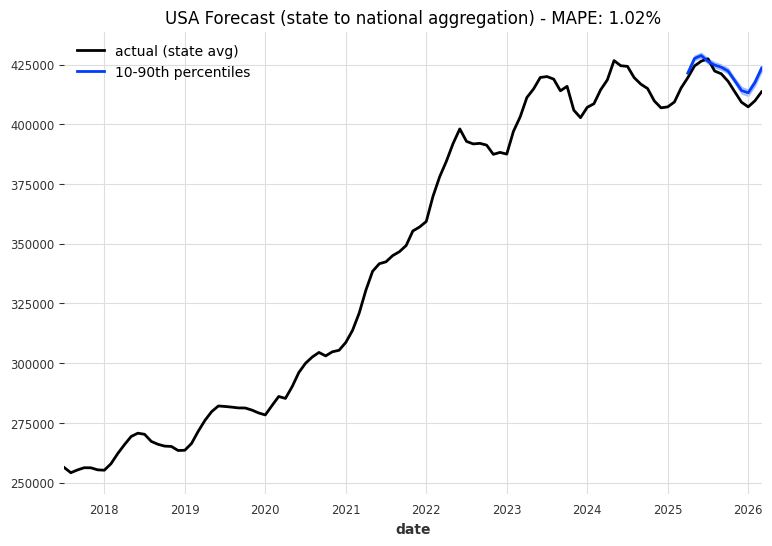

In [153]:
# Evaluate: predict for each state, compute per-state MAPE
state_preds = {}
state_mapes = {}

for i, (state_name, data) in enumerate(state_results.items()):
    
    pred = eval_model.predict(
        n=len(data['val_transformed']),
        series=data['train_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        num_samples=num_samples,
        verbose=False
    )
    state_preds[state_name] = pred
    state_mapes[state_name] = mape(data['val_transformed'], pred)

# Summary stats
mape_values = list(state_mapes.values())
print(f"State-level MAPE across {len(mape_values)} states:")
print(f"  Mean:   {np.mean(mape_values):.2f}%")
print(f"  Median: {np.median(mape_values):.2f}%")
print(f"  Min:    {np.min(mape_values):.2f}%")
print(f"  Max:    {np.max(mape_values):.2f}%")

# --- Aggregate state predictions to national level ---
from functools import reduce

national_actual_dfs = []
national_pred_samples = []  # keep all samples for quantile bands

for state_name, data in state_results.items():
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(state_preds[state_name])
    
    # Full actual series (train + val), not just validation
    full_inv = scaler.inverse_transform(data['series_transformed'])
    full_df = full_inv.to_dataframe()
    full_df.columns = [state_name]
    national_actual_dfs.append(full_df)
    
    # Keep all samples (shape: timesteps x 1 x num_samples) for quantile aggregation
    national_pred_samples.append(pred_inv.all_values())  # numpy array

# Full actual series averaged across states
national_actual_df = pd.concat(national_actual_dfs, axis=1).mean(axis=1).to_frame('median_listing_price_x')
national_actual_ts = TimeSeries.from_dataframe(national_actual_df, freq='MS')

# Average prediction samples across states → preserves quantile information
# Each element is (n_timesteps, 1, num_samples); stack and mean over states
national_pred_arr = np.mean(np.array(national_pred_samples), axis=0)  # (n_timesteps, 1, num_samples)

# Build a probabilistic TimeSeries from the averaged samples
pred_time_index = state_preds[list(state_results.keys())[0]].time_index
national_pred_ts = TimeSeries.from_times_and_values(
    times=pred_time_index,
    values=national_pred_arr,
)

national_mape = mape(
    national_actual_ts.slice(national_pred_ts.start_time(), national_pred_ts.end_time()),
    national_pred_ts,
)
print(f"\n  (USA) national aggregated MAPE: {national_mape:.2f}%")

# Plot national-level result with full actuals and quantile bands
plt.figure(figsize=figsize)
national_actual_ts.plot(label="actual (state avg)")
national_pred_ts.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
plt.title(f"USA Forecast (state to national aggregation) - MAPE: {national_mape:.2f}%")
plt.legend()

Forecasts generated for 51 states

State       MAPE%         RMSE          MAE     MASE Forecast Range
----------------------------------------------------------------------
  AK        3.12%      16,470      12,388    0.25   $406,698 → $415,078
  AL        6.09%      18,190      17,600    0.99   $273,585 → $275,021
  AR        7.10%      17,790      17,399    1.10   $228,194 → $230,095
  AZ        2.80%      13,171      12,654    0.46   $440,206 → $462,707
  CA        0.82%       6,998       5,854    0.20   $715,273 → $745,043
  CO        1.98%      13,772      12,556    0.31   $645,525 → $681,838
  CT        4.96%      31,160      28,006    0.80   $558,562 → $590,711
  DC       18.92%     109,726     106,710    2.22   $669,228 → $674,913
  DE        1.49%       9,919       7,057    0.24   $469,178 → $493,990
  FL        1.36%       7,402       5,667    0.22   $422,174 → $453,087
  GA        4.49%      16,393      15,474    0.71   $329,681 → $351,720
  HI        9.25%      93,788     

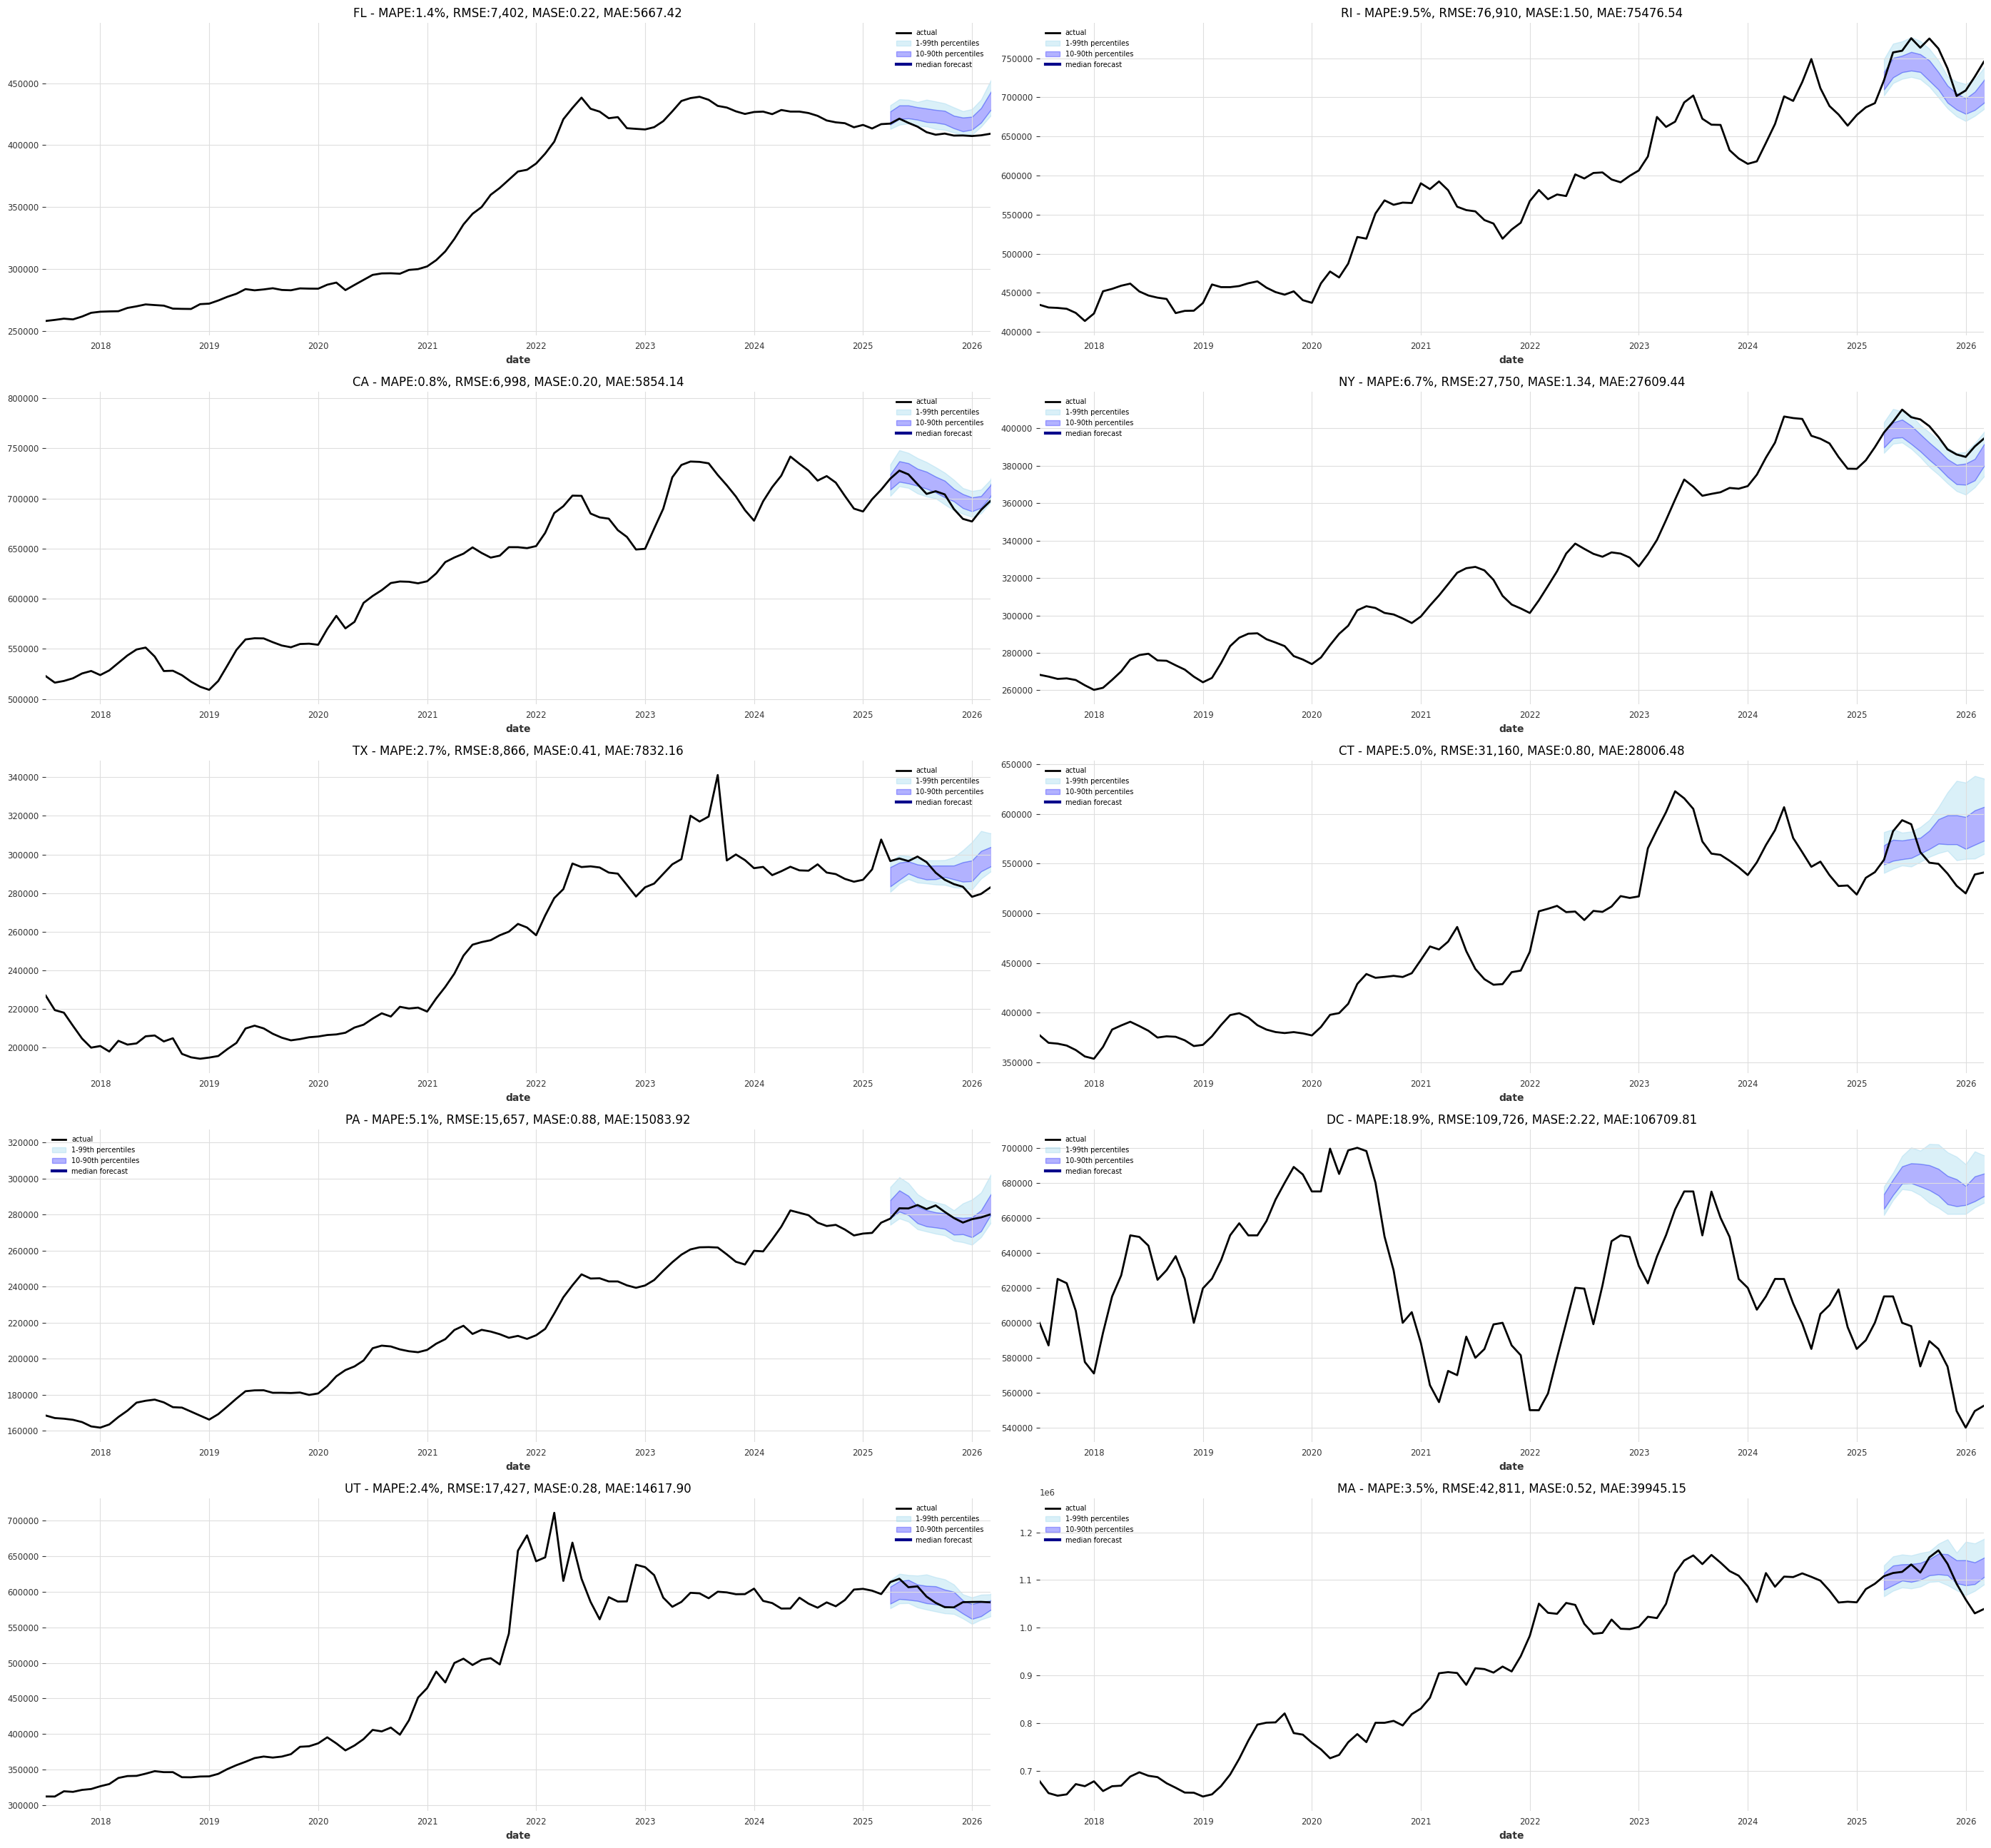

In [ ]:
#state-level predictions and metrics

# Settings
num_samples = 200
forecast_horizon = 18
low_q, high_q = 0.1, 0.9
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

# Generate predictions for each state
state_preds = {}
for state_name, data in state_results.items():
    pred = eval_model.predict(
        n=forecast_horizon,
        series=data['train_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        num_samples=num_samples,
        verbose=False,
    )
    state_preds[state_name] = pred

# Inverse-transform predictions back to original scale and compute metrics
state_preds_inv = {}
state_metrics = {}
for state_name, pred in state_preds.items():
    data = state_results[state_name]
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(pred)
    val_inv = scaler.inverse_transform(data['val_transformed'])
    train_inv = scaler.inverse_transform(data['train_transformed'])

    state_preds_inv[state_name] = pred_inv
    state_metrics[state_name] = {
        'MAPE': mape(val_inv, pred_inv),
        'RMSE': rmse(val_inv, pred_inv),
        'MAE': mae(val_inv, pred_inv),
        'MASE': mase(val_inv, pred_inv, insample=train_inv, m=12),
    }

# Print metrics per state
print(f"Forecasts generated for {len(state_preds)} states\n")
print(f"{'State':<8} {'MAPE%':>8} {'RMSE':>12} {'MAE':>12} {'MASE':>8} {'Forecast Range'}")
print("-" * 70)
for state_name in sorted(state_metrics.keys()):
    m = state_metrics[state_name]
    pred_inv = state_preds_inv[state_name]
    median_vals = np.median(pred_inv.all_values()[:, 0, :], axis=1)
    print(f"  {state_name.upper():<6} {m['MAPE']:>7.2f}% {m['RMSE']:>11,.0f} {m['MAE']:>11,.0f} {m['MASE']:>7.2f}   ${median_vals[0]:,.0f} → ${median_vals[-1]:,.0f}")

# Summary stats across all states
print(f"\n{'Metric':<8} {'Mean':>10} {'Median':>10} {'Min':>10} {'Max':>10}")
print("-" * 50)
for metric_name in ['MAPE', 'RMSE', 'MAE', 'MASE']:
    vals = [m[metric_name] for m in state_metrics.values()]
    fmt = '.2f' if metric_name in ['MAPE', 'MASE'] else ',.0f'
    print(f"  {metric_name:<6} {np.mean(vals):>10{fmt}} {np.median(vals):>10{fmt}} {np.min(vals):>10{fmt}} {np.max(vals):>10{fmt}}")

# Plot a few states
lowest_q, highest_q = 0.01, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"

sample_states = ['fl', 'ri', 'ca', 'ny', 'tx', 'ct', 'pa', 'dc', 'ut', 'ma']  # edit this list to select states
sample_states = [s for s in sample_states if s in state_results]

fig, axes = plt.subplots(5, 2, figsize=(28, 26))
axes = axes.flatten()

for ax, state_name in zip(axes, sample_states):
    data = state_results[state_name]
    scaler = data['scaler_target']
    actual_inv = scaler.inverse_transform(data['series_transformed'])
    pred_inv = state_preds_inv[state_name]
    m = state_metrics[state_name]
    
    # Extract time index and sample values for manual quantile bands
    times = pred_inv.time_index
    samples = pred_inv.all_values()[:, 0, :]  # (timesteps, num_samples)
    q_01 = np.quantile(samples, lowest_q, axis=1)
    q_10 = np.quantile(samples, low_q, axis=1)
    q_90 = np.quantile(samples, high_q, axis=1)
    q_99 = np.quantile(samples, highest_q, axis=1)
    q_50 = np.median(samples, axis=1)

    plt.sca(ax)
    actual_inv.plot(label="actual")
    # Outer band (1-10th and 90-99th percentiles) in sky blue
    ax.fill_between(times, q_01, q_10, alpha=0.3, color='skyblue', label=label_q_outer)
    ax.fill_between(times, q_90, q_99, alpha=0.3, color='skyblue')
    # Inner band (10-90th percentiles)
    ax.fill_between(times, q_10, q_90, alpha=0.3, color='blue', label=label_q_inner)
    # Median line
    ax.plot(times, q_50, color='darkblue', linewidth=3, label="median forecast")
    
    ax.set_title(f"{state_name.upper()} - MAPE:{m['MAPE']:.1f}%, RMSE:{m['RMSE']:,.0f}, MASE:{m['MASE']:.2f}, MAE:{m['MAE']:.2f}")
    ax.legend(fontsize=7)

for ax in axes[len(sample_states):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Future

### Future - USA

Future forecasts generated for 51 states

National 12-Month Future Forecast (state average)
  Period: 2026-04 → 2027-09
  Median: $413,849 → $424,655
  90% range: $412,853–$415,029 → $422,680–$426,612


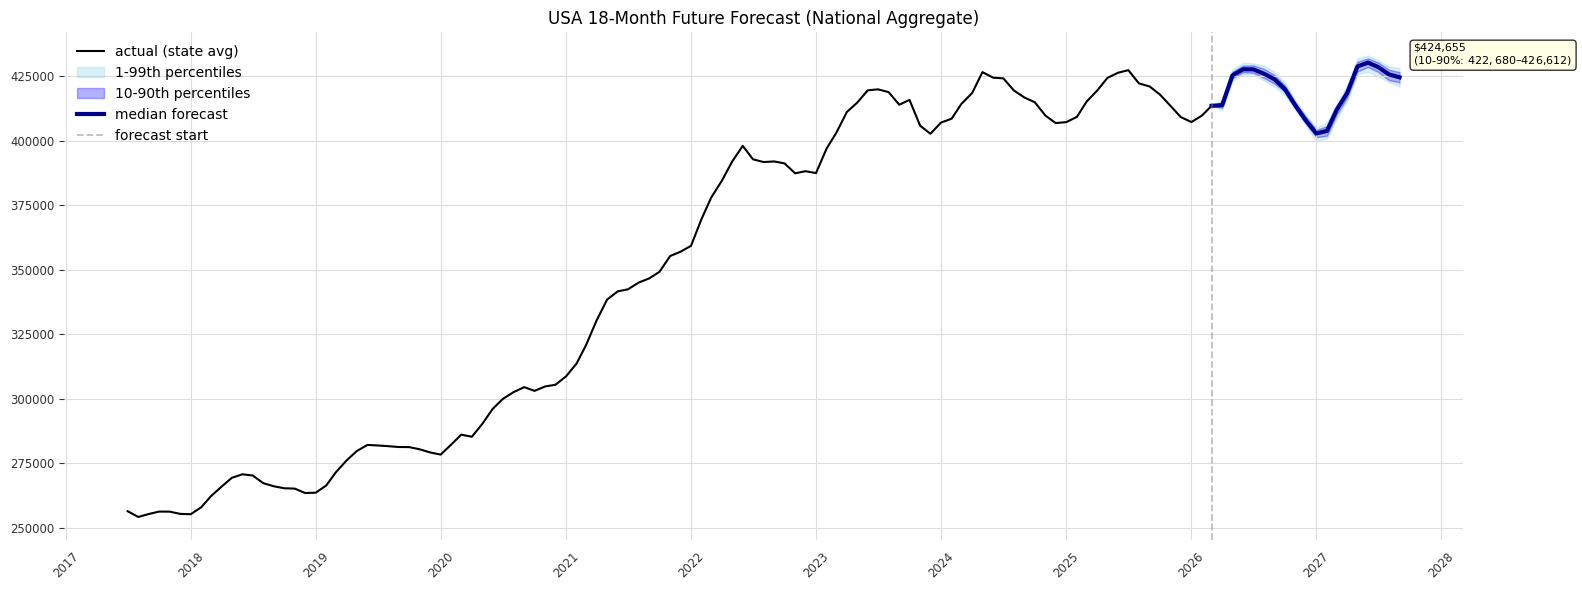

In [ ]:
# 18-month future forecast — national aggregate
# Uses the FULL series (train + val) to predict the next 18 months beyond available data

future_preds = {}
skipped_future = []
output_chunk_length = forecast_horizon + 6  # must match model's output_chunk_length (18)

for state_name, data in state_results.items():
    scaler = data['scaler_target']
    full_series = data['series_transformed']
    past_cov = data['past_cov_transformed']

    # Extend future covariates on UNSCALED data, then re-scale the whole thing
    # This avoids injecting raw values (e.g. year=2026) into an already-scaled DataFrame
    fut_cov_unscaled = data['fut_cov_unscaled']
    scaler_future = data['scaler_future']

    if fut_cov_unscaled.end_time() < full_series.end_time() + pd.DateOffset(months=output_chunk_length - 1):
        fut_df = fut_cov_unscaled.to_dataframe()
        extra_months = output_chunk_length
        future_dates = pd.date_range(
            start=fut_df.index[-1] + pd.DateOffset(months=1),
            periods=extra_months,
            freq='MS',
        )
        extension = pd.DataFrame([fut_df.iloc[-1]] * extra_months, index=future_dates)
        # Update time-varying columns with proper values for each future date
        if 'year' in extension.columns:
            extension['year'] = [d.year for d in future_dates]
        if 'linear_increase' in extension.columns:
            last_val = fut_df['linear_increase'].iloc[-1]
            extension['linear_increase'] = np.arange(last_val + 1, last_val + 1 + extra_months)
        # Recalculate month sin/cos for future dates (must cycle correctly, not be frozen)
        if 'month_sin' in extension.columns:
            extension['month_sin'] = np.sin(2 * np.pi * np.array([d.month for d in future_dates]) / 12)
        if 'month_cos' in extension.columns:
            extension['month_cos'] = np.cos(2 * np.pi * np.array([d.month for d in future_dates]) / 12)
        fut_extended_df = pd.concat([fut_df, extension]).astype(np.float32)
        fut_cov_extended = TimeSeries.from_dataframe(fut_extended_df, freq='MS')
        # Scale the entire extended series using the stored scaler
        fut_cov = scaler_future.transform(fut_cov_extended)
    else:
        fut_cov = data['future_cov_transformed']

    try:
        pred = full_model.predict(
            n=forecast_horizon,
            series=full_series,
            future_covariates=fut_cov,
            past_covariates=past_cov,
            num_samples=num_samples,
            verbose=False,
        )
        future_preds[state_name] = pred
    except Exception as e:
        skipped_future.append((state_name, str(e)))

print(f"Future forecasts generated for {len(future_preds)} states")

if skipped_future:
    print(f"Skipped {len(skipped_future)} states:")
    for name, reason in skipped_future:
        print(f"  {name}: {reason}")

# Inverse-transform and aggregate to national level
national_future_samples = []
national_actual_dfs = []

for state_name, pred in future_preds.items():
    scaler = state_results[state_name]['scaler_target']
    pred_inv = scaler.inverse_transform(pred)
    national_future_samples.append(pred_inv.all_values())  # (timesteps, 1, num_samples)

    # Full actual history for plotting
    full_inv = scaler.inverse_transform(state_results[state_name]['series_transformed'])
    full_df = full_inv.to_dataframe()
    full_df.columns = [state_name]
    national_actual_dfs.append(full_df)

# National average: actual history
national_actual_df = pd.concat(national_actual_dfs, axis=1).mean(axis=1).to_frame('median_listing_price_x')
national_actual_ts = TimeSeries.from_dataframe(national_actual_df, freq='MS')

# National average: future prediction samples
national_future_arr = np.mean(np.array(national_future_samples), axis=0)  # (timesteps, 1, num_samples)
future_time_index = future_preds[list(future_preds.keys())[0]].time_index
national_future_ts = TimeSeries.from_times_and_values(
    times=future_time_index,
    values=national_future_arr,
)

# Extract quantile bands
samples = national_future_arr[:, 0, :]  # (timesteps, num_samples)
q_01 = np.quantile(samples, lowest_q, axis=1)
q_10 = np.quantile(samples, low_q, axis=1)
q_90 = np.quantile(samples, high_q, axis=1)
q_99 = np.quantile(samples, highest_q, axis=1)
q_50 = np.median(samples, axis=1)

# Print forecast summary
print(f"\nNational 18-Month Future Forecast (state average)")
print(f"  Period: {future_time_index[0].strftime('%Y-%m')} → {future_time_index[-1].strftime('%Y-%m')}")
print(f"  Median: ${q_50[0]:,.0f} → ${q_50[-1]:,.0f}")
print(f"  90% range: ${q_10[0]:,.0f}–${q_90[0]:,.0f} → ${q_10[-1]:,.0f}–${q_90[-1]:,.0f}")

# Plot — full history + 18-month forecast
fig, ax = plt.subplots(figsize=(16, 6))
actual_times = national_actual_ts.time_index
actual_vals = national_actual_ts.values().flatten()
ax.plot(actual_times, actual_vals, color='black', linewidth=1.5, label="actual (state avg)")
# Prepend last actual point so forecast bands start seamlessly from actuals
last_actual_val = actual_vals[-1]
fti_ext = pd.DatetimeIndex([actual_times[-1]]).append(future_time_index)
q_01_ext = np.concatenate([[last_actual_val], q_01])
q_10_ext = np.concatenate([[last_actual_val], q_10])
q_90_ext = np.concatenate([[last_actual_val], q_90])
q_99_ext = np.concatenate([[last_actual_val], q_99])
q_50_ext = np.concatenate([[last_actual_val], q_50])
ax.fill_between(fti_ext, q_01_ext, q_10_ext, alpha=0.3, color='skyblue', label=label_q_outer)
ax.fill_between(fti_ext, q_90_ext, q_99_ext, alpha=0.3, color='skyblue')
ax.fill_between(fti_ext, q_10_ext, q_90_ext, alpha=0.3, color='blue', label=label_q_inner)
ax.plot(fti_ext, q_50_ext, color='darkblue', linewidth=3, label="median forecast")
ax.axvline(x=national_actual_ts.end_time(), color='gray', linestyle='--', alpha=0.5, label='forecast start')

# Annotate final forecast range
ax.annotate(f'${q_50[-1]:,.0f}\n({int(low_q*100)}-{int(high_q*100)}%: ${q_10[-1]:,.0f}–${q_90[-1]:,.0f})',
            xy=(future_time_index[-1], q_50[-1]), fontsize=8,
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))

plt.xticks(rotation=45)
ax.set_title("USA 18-Month Future Forecast (National Aggregate)")
ax.legend()
plt.tight_layout()
plt.show()

## Future — By State

State           Start          End   Median Start     Median End 90% Range End
--------------------------------------------------------------------------------
  AK          2026-04      2027-09   $   424,110   $   412,791   $398,132–$433,735
  AL          2026-04      2027-09   $   271,361   $   280,157   $273,251–$285,666
  AR          2026-04      2027-09   $   219,234   $   230,319   $224,561–$235,997
  AZ          2026-04      2027-09   $   436,137   $   447,161   $436,924–$458,973
  CA          2026-04      2027-09   $   706,970   $   728,646   $717,857–$737,998
  CO          2026-04      2027-09   $   633,996   $   651,541   $633,372–$670,916
  CT          2026-04      2027-09   $   563,958   $   575,623   $565,589–$586,037
  DC          2026-04      2027-09   $   654,480   $   665,672   $659,864–$671,597
  DE          2026-04      2027-09   $   454,065   $   474,588   $462,921–$486,729
  FL          2026-04      2027-09   $   415,011   $   426,566   $412,805–$438,377
  GA      

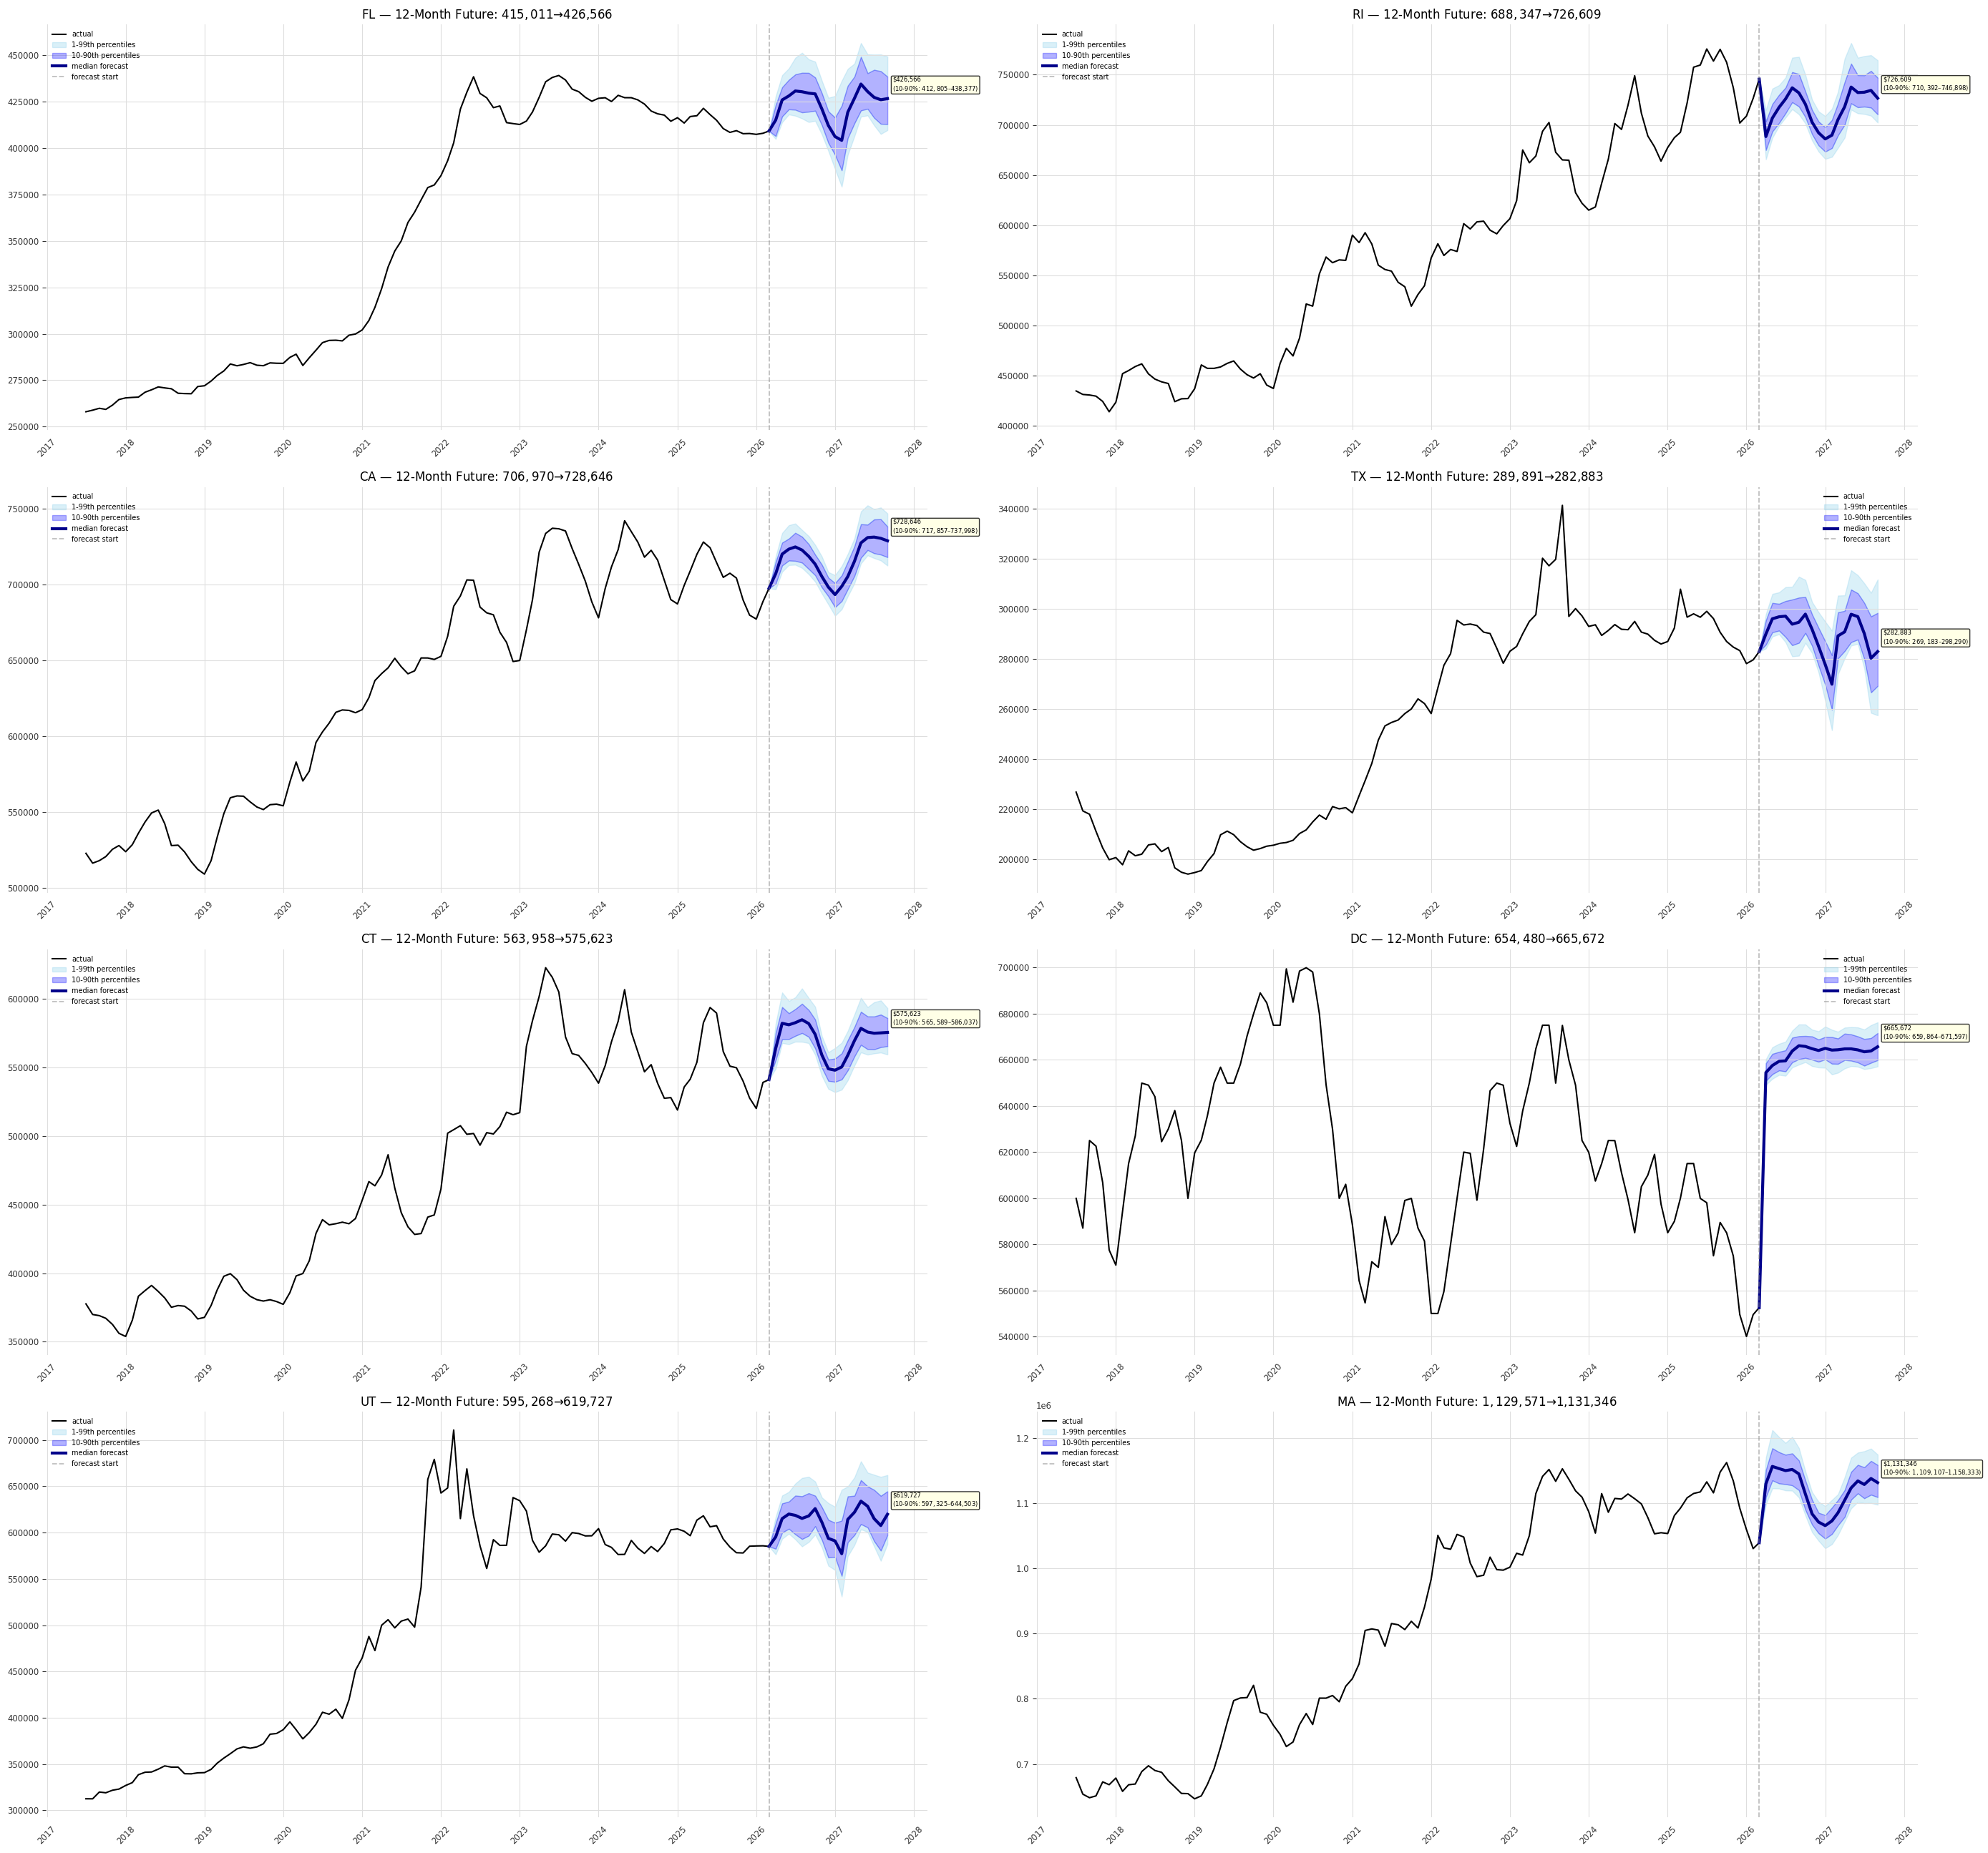

In [157]:
# 18-month future forecast — by state

sample_states_future = ['fl', 'ri', 'ca', 'tx', 'ct', 'dc', 'ut', 'ma']
sample_states_future = [s for s in sample_states_future if s in future_preds]

# Inverse-transform all predictions
future_preds_inv = {}
for state_name, pred in future_preds.items():
    scaler = state_results[state_name]['scaler_target']
    future_preds_inv[state_name] = scaler.inverse_transform(pred)

# Print per-state forecast table
print(f"{'State':<8} {'Start':>12} {'End':>12} {'Median Start':>14} {'Median End':>14} {'90% Range End'}")
print("-" * 80)
for state_name in sorted(future_preds_inv.keys()):
    pred_inv = future_preds_inv[state_name]
    samples = pred_inv.all_values()[:, 0, :]
    q_50 = np.median(samples, axis=1)
    q_10 = np.quantile(samples, low_q, axis=1)
    q_90 = np.quantile(samples, high_q, axis=1)
    t0 = pred_inv.time_index[0].strftime('%Y-%m')
    t1 = pred_inv.time_index[-1].strftime('%Y-%m')
    print(f"  {state_name.upper():<6} {t0:>12} {t1:>12}   ${q_50[0]:>10,.0f}   ${q_50[-1]:>10,.0f}   ${q_10[-1]:,.0f}–${q_90[-1]:,.0f}")

# Plot by state
fig, axes = plt.subplots(4, 2, figsize=(28, 26))
axes = axes.flatten()

for ax, state_name in zip(axes, sample_states_future):
    data = state_results[state_name]
    scaler = data['scaler_target']
    actual_inv = scaler.inverse_transform(data['series_transformed'])
    pred_inv = future_preds_inv[state_name]

    # Quantile bands
    times = pred_inv.time_index
    samples = pred_inv.all_values()[:, 0, :]
    q_01 = np.quantile(samples, lowest_q, axis=1)
    q_10 = np.quantile(samples, low_q, axis=1)
    q_90 = np.quantile(samples, high_q, axis=1)
    q_99 = np.quantile(samples, highest_q, axis=1)
    q_50 = np.median(samples, axis=1)

    plt.sca(ax)
    # Plot actual history using matplotlib directly (darts .plot() overrides axis formatting)
    act_times = actual_inv.time_index
    act_vals = actual_inv.values().flatten()
    ax.plot(act_times, act_vals, color='black', linewidth=1.5, label="actual")
    # Prepend last actual point so forecast bands start seamlessly from actuals
    last_actual_val = act_vals[-1]
    times_ext = pd.DatetimeIndex([act_times[-1]]).append(times)
    q_01_ext = np.concatenate([[last_actual_val], q_01])
    q_10_ext = np.concatenate([[last_actual_val], q_10])
    q_90_ext = np.concatenate([[last_actual_val], q_90])
    q_99_ext = np.concatenate([[last_actual_val], q_99])
    q_50_ext = np.concatenate([[last_actual_val], q_50])
    ax.fill_between(times_ext, q_01_ext, q_10_ext, alpha=0.3, color='skyblue', label=label_q_outer)
    ax.fill_between(times_ext, q_90_ext, q_99_ext, alpha=0.3, color='skyblue')
    ax.fill_between(times_ext, q_10_ext, q_90_ext, alpha=0.3, color='blue', label=label_q_inner)
    ax.plot(times_ext, q_50_ext, color='darkblue', linewidth=3, label="median forecast")
    ax.axvline(x=actual_inv.end_time(), color='gray', linestyle='--', alpha=0.5, label='forecast start')

    # Annotate final forecast range
    ax.annotate(f'${q_50[-1]:,.0f}\n({int(low_q*100)}-{int(high_q*100)}%: ${q_10[-1]:,.0f}–${q_90[-1]:,.0f})',
                xy=(times[-1], q_50[-1]), fontsize=6,
                xytext=(5, 8), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(f"{state_name.upper()} — 12-Month Future: ${q_50[0]:,.0f} → ${q_50[-1]:,.0f}")
    ax.legend(fontsize=7)


for ax in axes[len(sample_states_future):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()